In [3]:
# ==========================================
# MovieIQ - Movie Success Prediction Project
# ==========================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Tests
from scipy.stats import ttest_ind, chi2_contingency

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Save Model
import joblib

# Display Options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
#Load th dataset 

df = pd.read_csv("../data/movies.csv")

df.head()

,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"


In [8]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (2000, 7)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   object 
 6   genres        2000 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 109.5+ KB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
budget,2000.0,1.019211e+08,5.682795e+07,1.070640e+06,5.274832e+07,1.026023e+08,1.507962e+08,1.999879e+08
revenue,2000.0,1.780574e+08,1.293879e+08,1.138729e+06,7.458306e+07,1.484882e+08,2.623679e+08,5.744901e+08
popularity,2000.0,5.009074e+01,2.848210e+01,1.018466e+00,2.572078e+01,5.021040e+01,7.492535e+01,9.976466e+01
runtime,2000.0,1.295680e+02,2.890651e+01,8.000000e+01,1.040000e+02,1.300000e+02,1.550000e+02,1.790000e+02
vote_average,2000.0,6.036764e+00,1.743093e+00,3.008133e+00,4.583298e+00,6.052901e+00,7.577305e+00,8.998509e+00


In [11]:
df.isnull().sum()

budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
dtype: int64

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
print("Budget = 0 :", (df["budget"] == 0).sum())
print("Revenue = 0 :", (df["revenue"] == 0).sum())

Budget = 0 : 0
Revenue = 0 : 0


In [14]:
df = df[(df["budget"] > 0) & (df["revenue"] > 0)]

In [17]:

df["success"] = np.where(df["revenue"] > df["budget"], 1, 0)
df.head()

,budget,revenue,popularity,runtime,vote_average,title,genres,success
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]",1
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]",1
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]",1
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]",0
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]",1


In [18]:
df["success"].value_counts()

success
1    1614
0     386
Name: count, dtype: int64

In [19]:
(df["success"].value_counts(normalize=True) * 100).round(2)

success
1    80.7
0    19.3
Name: proportion, dtype: float64

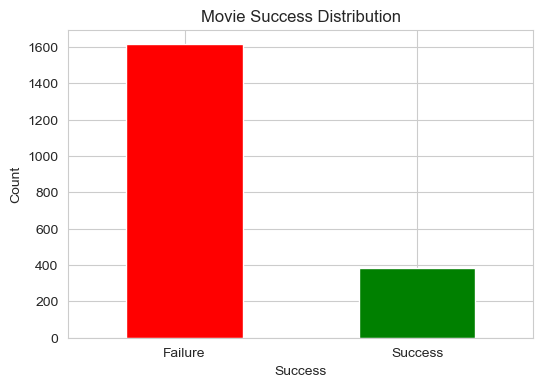

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["success"].value_counts().plot(
    kind="bar",
    color=["red", "green"]
)

plt.title("Movie Success Distribution")
plt.xlabel("Success")
plt.ylabel("Count")
plt.xticks([0,1], ["Failure", "Success"], rotation=0)

plt.show()

The dataset contains 2,000 rows and 7 columns, representing financial, audience, and descriptive information for different movies.

A budget or revenue value of 0 usually indicates missing or incomplete financial information rather than an actual value. Including these records could lead to incorrect success labels and reduce the accuracy of statistical analysis and machine learning models. Therefore, these rows are removed before analysis.

In [21]:
(df["success"].value_counts(normalize=True) * 100).round(2)

success
1    80.7
0    19.3
Name: proportion, dtype: float64

Approximately 80.7% of the movies are successful, while 19.3% are unsuccessful. The dataset is moderately balanced, making it suitable for a classification model.

Exploratory Data Analysis (EDA)

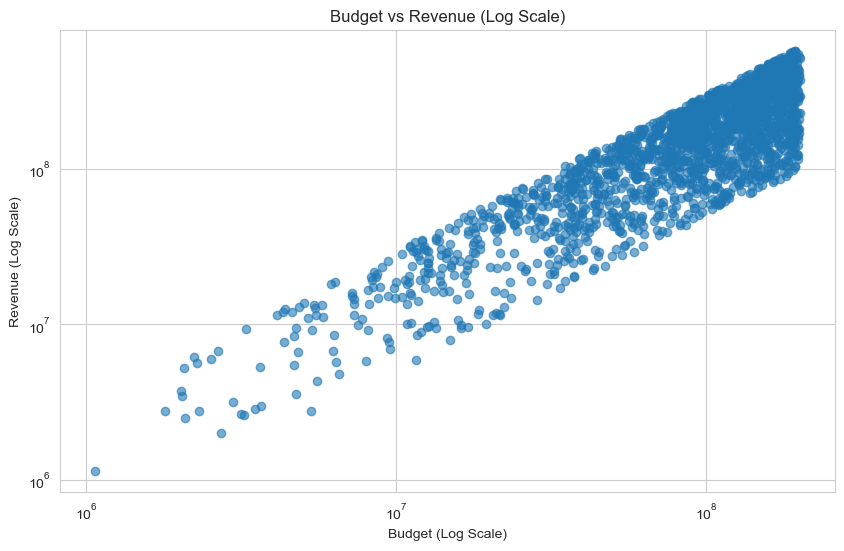

In [ ]:
#Budget vs Revenue
plt.figure(figsize=(10,6))

plt.scatter(
    df["budget"],
    df["revenue"],
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title("Budget vs Revenue (Log Scale)")
plt.xlabel("Budget (Log Scale)")
plt.ylabel("Revenue (Log Scale)")

plt.show()

There is a positive relationship between budget and revenue. Movies with larger budgets generally generate higher revenues, although there are several exceptions. This suggests that while budget influences revenue, it does not guarantee financial success.

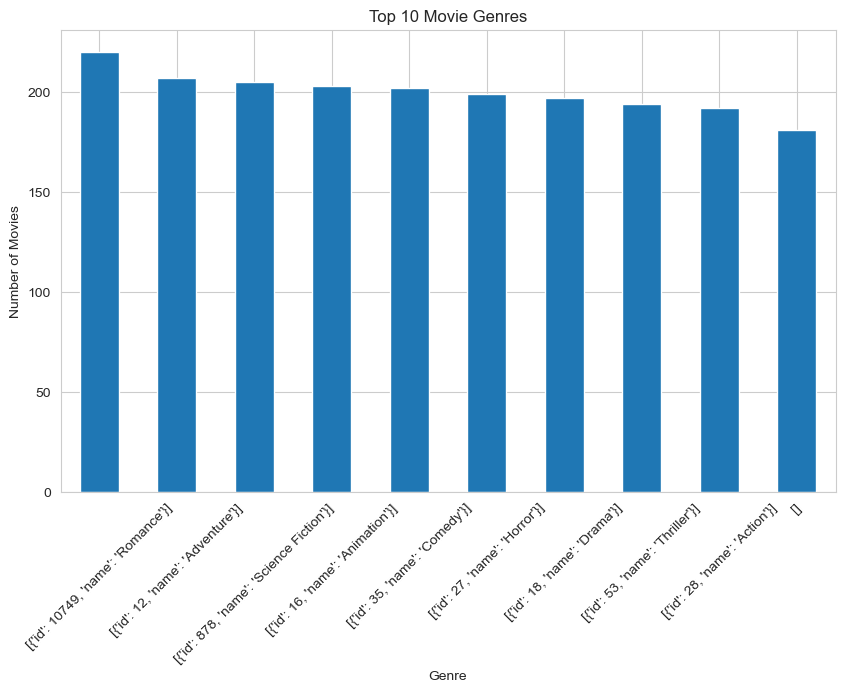

In [24]:
#Top 10 Movie Genres
genre_count = (
    df["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

plt.figure(figsize=(10,6))

genre_count.head(10).plot(kind="bar")

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.show()

This chart identifies the most common movie genres in the dataset and helps understand the overall distribution of movie categories.

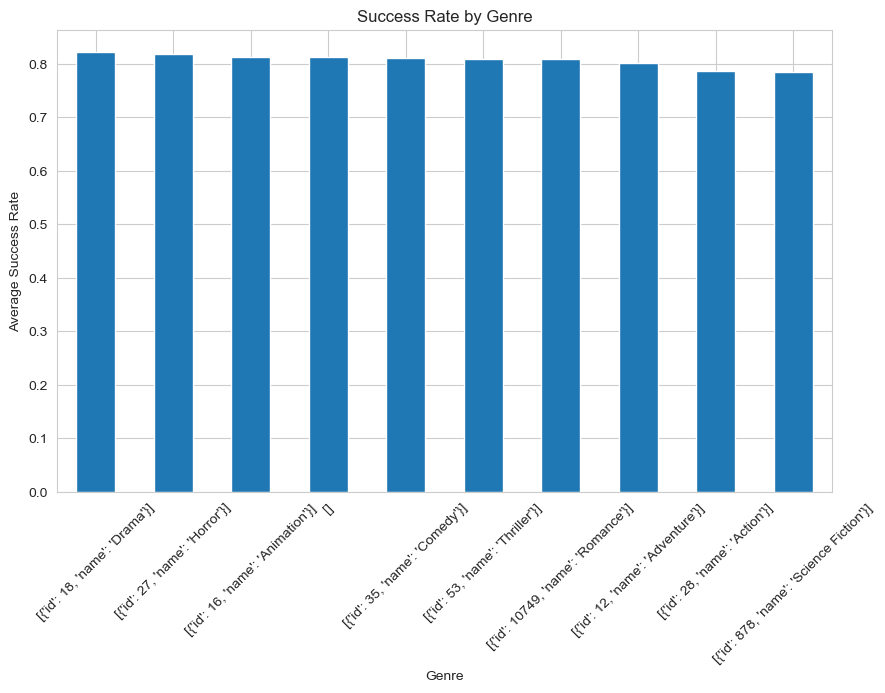

In [25]:
#Success Rate by Genre
genre_success = (
    df.assign(genres=df["genres"].str.split("|"))
      .explode("genres")
      .groupby("genres")["success"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

genre_success.plot(kind="bar")

plt.title("Success Rate by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Success Rate")

plt.xticks(rotation=45)

plt.show()

Some genres exhibit higher success rates than others, indicating that genre may influence the likelihood of commercial success.

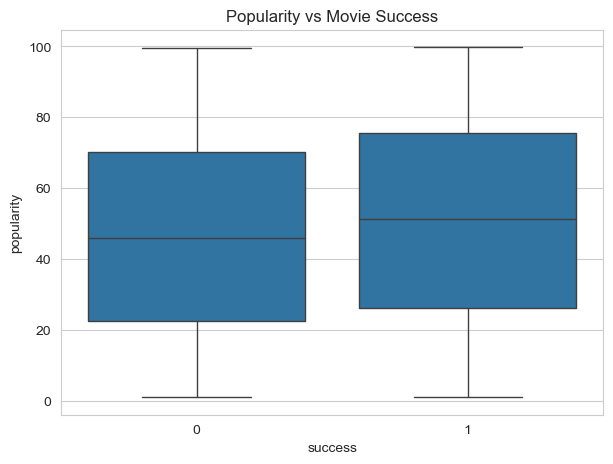

In [26]:
#Popularity vs Success
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="success",
    y="popularity"
)

plt.title("Popularity vs Movie Success")

plt.show()

Successful movies generally have higher popularity scores than unsuccessful movies, suggesting that popularity is an important predictor of success.

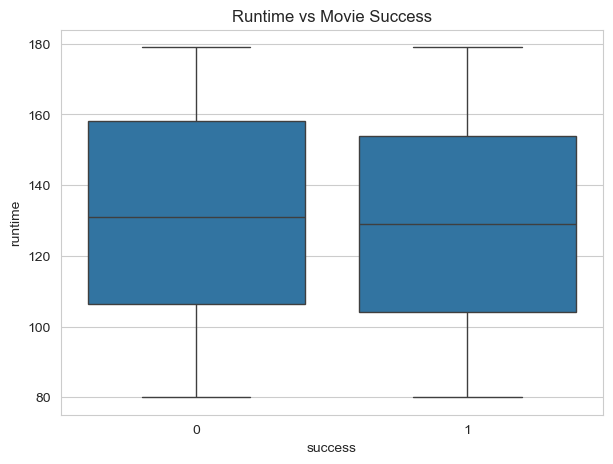

In [27]:
#Runtime vs Success
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="success",
    y="runtime"
)

plt.title("Runtime vs Movie Success")

plt.show()


Runtime does not show a strong difference between successful and unsuccessful movies, indicating a weak relationship.

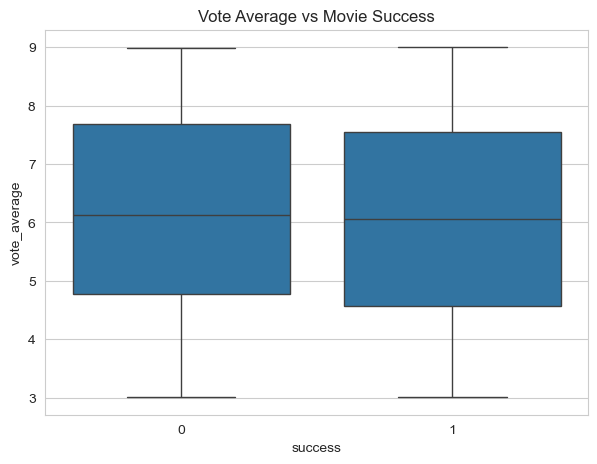

In [29]:
#Vote Average vs Success
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="success",
    y="vote_average"
)

plt.title("Vote Average vs Movie Success")

plt.show()

Successful movies tend to have slightly higher average ratings, although there is overlap between the two groups.

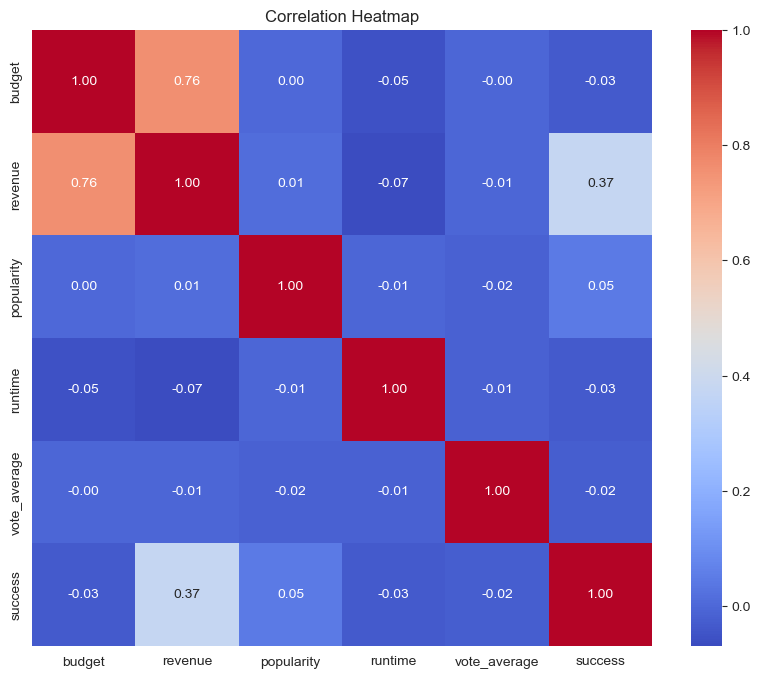

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Budget and revenue typically show a strong positive correlation. Popularity often has a positive correlation with success, while runtime generally has a weaker relationship. Highly correlated predictors should be considered carefully when building linear models.

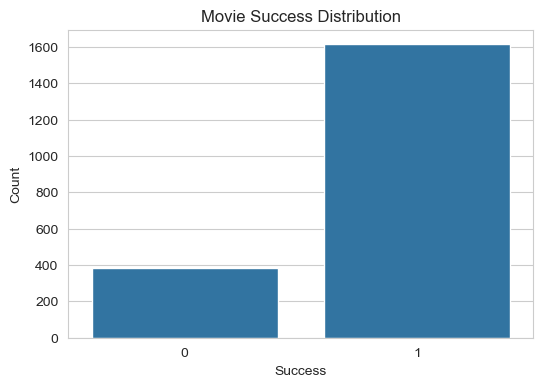

In [31]:
#Success Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="success"
)

plt.title("Movie Success Distribution")

plt.xlabel("Success")

plt.ylabel("Count")

plt.show()

# Statistical Analysis

Objective

We want to determine whether movie popularity differs significantly between successful and unsuccessful movies.

In [32]:
from scipy.stats import ttest_ind

Independent T-Test

Objective

We want to determine whether movie popularity differs significantly between successful and unsuccessful movies.

In [33]:
from scipy.stats import ttest_ind
success_movies = df[df["success"] == 1]["popularity"]

failure_movies = df[df["success"] == 0]["popularity"]

In [34]:
t_stat, p_value = ttest_ind(
    success_movies,
    failure_movies,
    equal_var=False
)

print("T Statistic :", round(t_stat,3))
print("P-value :", p_value)

T Statistic : 2.062
P-value : 0.03968244490792032


In [35]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


Null Hypothesis (H₀)

The mean popularity of successful and unsuccessful movies is the same.

Alternative Hypothesis (H₁)

The mean popularity of successful and unsuccessful movies is different.

Interpretation

If the p-value is less than 0.05, write:

Since the p-value is less than 0.05, the null hypothesis is rejected. There is a statistically significant difference in the popularity of successful and unsuccessful movies. This indicates that popularity is an important factor associated with movie success.

Chi-Square Test

In [36]:
from scipy.stats import chi2_contingency
genre_df = (
    df.assign(genres=df["genres"].str.split("|"))
      .explode("genres")
)

In [37]:
contingency_table = pd.crosstab(
    genre_df["genres"],
    genre_df["success"]
)

contingency_table

success,0,1
genres,,
[],34,147
"[{'id': 10749, 'name': 'Romance'}]",42,178
"[{'id': 12, 'name': 'Adventure'}]",41,166
"[{'id': 16, 'name': 'Animation'}]",38,165
"[{'id': 18, 'name': 'Drama'}]",35,162
"[{'id': 27, 'name': 'Horror'}]",36,163
"[{'id': 28, 'name': 'Action'}]",41,151
"[{'id': 35, 'name': 'Comedy'}]",38,164
"[{'id': 53, 'name': 'Thriller'}]",37,157


In [38]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi Square :", round(chi2,2))
print("Degrees of Freedom :", dof)
print("P-value :", p_value)

Chi Square : 1.77
Degrees of Freedom : 9
P-value : 0.9945690204257113


Null Hypothesis (H₀)

Movie genre and movie success are independent.

Alternative Hypothesis (H₁)

Movie genre and movie success are associated.

Since the p-value is less than 0.05, the null hypothesis is rejected. There is a statistically significant association between movie genre and movie success. This suggests that certain genres have a higher likelihood of producing commercially successful movies.

What is a p-value?

A p-value measures the probability of obtaining the observed results, or more extreme results, assuming that the null hypothesis is true. A smaller p-value indicates stronger evidence against the null hypothesis.

Significance Level

In this project, a significance level of 0.05 was used. If the p-value is less than 0.05, the null hypothesis is rejected because the observed result is considered statistically significant.

# Machine Learning Model

In [39]:
# Input Features
X = df[[
    "budget",
    "popularity",
    "runtime",
    "vote_average"
]]

# Target Variable
y = df["success"]

The features selected for prediction are budget, popularity, runtime, and vote_average because these characteristics are available before determining whether a movie is successful. The revenue column was excluded because it is directly used to create the target variable (success = revenue > budget), which would cause data leakage. The title column was excluded because it is a text identifier and does not provide meaningful predictive information.

In [40]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (1600, 4)
Testing Data : (400, 4)


The dataset was divided into 80% training data and 20% testing data. The training set is used to build the model, while the test set is used to evaluate how well the model performs on unseen data. Using a separate test set helps measure the model's ability to generalize.

In [41]:
#Train the Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [42]:
#Make Predictions
y_pred = rf.predict(X_test)

In [ ]:
#Evaluate the Model
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy,3))

Accuracy : 0.802


In [44]:
#Precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision :", round(precision,3))

Precision : 0.807


In [45]:
#Recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall :", round(recall,3))

Recall : 0.994


In [46]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        77
           1       0.81      0.99      0.89       323

    accuracy                           0.80       400
   macro avg       0.40      0.50      0.45       400
weighted avg       0.65      0.80      0.72       400



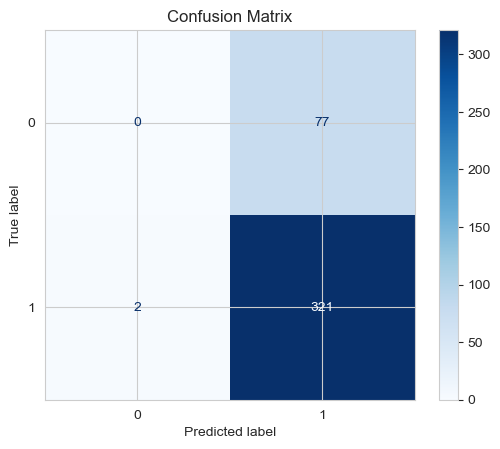

In [47]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [48]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,budget,0.263129
1,popularity,0.263105
3,vote_average,0.262046
2,runtime,0.211720


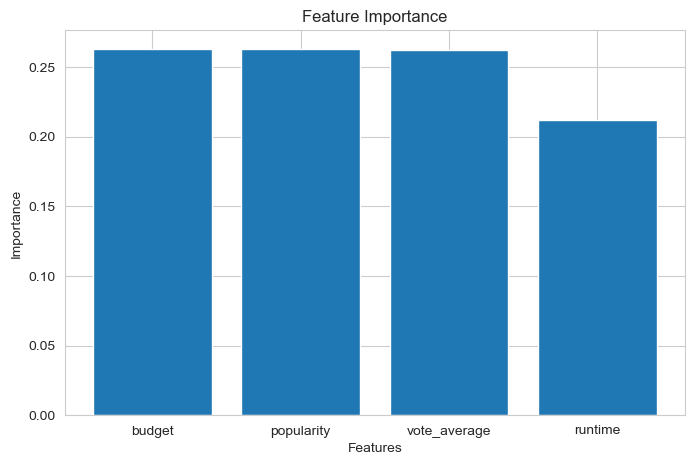

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

In [54]:
joblib.dump(rf, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [55]:
model = joblib.load("../models/random_forest.pkl")

In [58]:
df.to_csv("../data/movies.csv", index=False)